<a href="https://colab.research.google.com/github/CarlosTora/Machine-Learning/blob/16_Segmentacion_Imagenes/16_Ejercicio_Segmentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/c/ultrasound-nerve-segmentation/data

Este ejercicio consiste en segmentar un conjunto de nervios llamados Plexo Braquial (BP) en imágenes de ultrasonido. Se proporciona un gran conjunto de imágenes de entrenamiento donde el nervio ha sido anotado manualmente por humanos. Los anotadores fueron capacitados por expertos e instruidos para anotar imágenes en las que se sentían seguros acerca de la existencia del punto de referencia de BP.

Puntos importantes:

El conjunto de datos contiene imágenes donde el BP no está presente. el algoritmo no debe predecir valores de píxeles en estos casos.
Al igual que con todos los datos etiquetados por humanos, cabe esperar encontrar ruido, artefactos y posibles errores en las máscaras etiquetadas.

In [2]:
!pip install --upgrade --no-cache-dir gdown
## Para evitar un error de permiso

#!gdown --id 10NPOJVzi7NP14mszsJnjn0uUtUpTP0zo
!gdown --id 1_T1uySANYcGTtV-lv6jXFmQT0eixtYFS


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1_T1uySANYcGTtV-lv6jXFmQT0eixtYFS
From (redirected): https://drive.google.com/uc?id=1_T1uySANYcGTtV-lv6jXFmQT0eixtYFS&confirm=t&uuid=2d4e683f-19c1-4af8-8a6e-611c977db212
To: /content/ultrasound-nerve-segmentation.zip
100% 2.27G/2.27G [00:26<00:00, 85.4MB/s]


In [3]:
!unzip ultrasound-nerve-segmentation.zip > /dev/null

In [4]:
!pip install imagecodecs
# Reset runtime after install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 14.3 MB/s eta 0:00:00


In [5]:
# for reading and processing images
import imageio
from PIL import Image
import tifffile
# import imagecodecs
import cv2

import os
import random

# for visualizations
import matplotlib.pyplot as plt

import tensorflow.keras as keras
import numpy as np # for using np arrays
from numpy import asarray

# for bulding and running deep learning model
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.losses import binary_crossentropy
from sklearn.model_selection import train_test_split

# Carga de datos

In [6]:
def LoadData (path):
    # Read the images folder like a list
    image_dataset = os.listdir(path)

    # Make a list for images and masks filenames
    orig_img = []
    mask_img = []
    image_dataset.sort()
    for file in image_dataset:
        if file.endswith('_mask.tif'):
            mask_img.append(file)
            orig_img.append(file.replace("_mask.tif",".tif"))

    # Sort the lists to get both of them in same order (the dataset has exactly the same name for images and corresponding masks)
    # orig_img.sort()
    # mask_img.sort()

    return orig_img, mask_img

(420, 580)
(420, 580)


<ipython-input-7-d63b097b22eb>:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_view  = imageio.imread(path + img[show_images])
<ipython-input-7-d63b097b22eb>:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_view = imageio.imread(path + mask[show_images])


Text(0.5, 1.0, 'Masked Image 11_113_mask.tif')

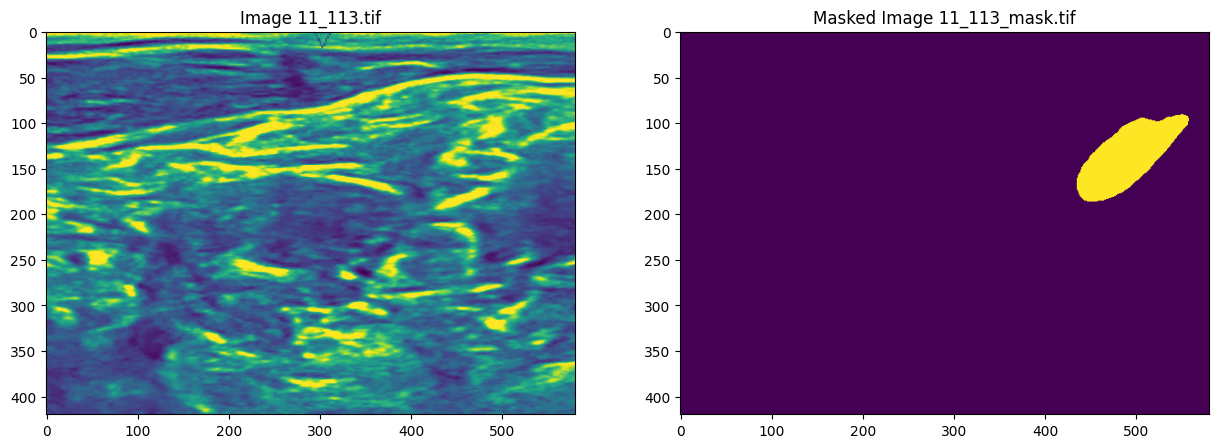

In [7]:
path = 'train/'
img, mask = LoadData(path)

show_images = 134

img_view  = imageio.imread(path + img[show_images])
mask_view = imageio.imread(path + mask[show_images])

print(img_view.shape)
print(mask_view.shape)
fig, arr = plt.subplots(1, 2, figsize=(15, 15))
arr[0].imshow(img_view)
arr[0].set_title('Image ' + img[show_images])
arr[1].imshow(mask_view)
arr[1].set_title('Masked Image '+ mask[show_images])

In [8]:
def PreprocessData(img, mask, target_shape_img, target_shape_mask, path):
    """
    Processes the images and mask present in the shared list and path
    Returns a NumPy dataset with images as 3-D arrays of desired size
    Please note the masks in this dataset have only one channel
    """
    # Pull the relevant dimensions for image and mask
    m = len(img)                     # number of images
    i_h,i_w,i_c = target_shape_img   # pull height, width, and channels of image
    m_h,m_w,m_c = target_shape_mask  # pull height, width, and channels of mask

    # Define X and Y as number of images along with shape of one image
    X = np.zeros((m,i_h,i_w,i_c), dtype=np.float32)
    y = np.zeros((m,m_h,m_w,m_c), dtype=np.int32)

    # Resize images and masks
    for file in img:
        # convert image into an array of desired shape (3 channels)
        index = img.index(file)
        path1 = os.path.join(path, file)
        single_img = Image.open(path1).convert('RGB')
        single_img = single_img.resize((i_h,i_w))
        single_img = np.reshape(single_img,(i_h,i_w,i_c))
        single_img = single_img/256.
        X[index] = single_img

        # convert mask into an array of desired shape (1 channel)

        single_mask_ind = mask[index]
        path1 = os.path.join(path, single_mask_ind)
        single_mask = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
        single_mask = cv2.resize(single_mask, dsize=(m_h, m_w), interpolation=cv2.INTER_NEAREST)
        single_mask = asarray(single_mask)
        single_mask = single_mask[..., tf.newaxis]
        single_mask = np.reshape(single_mask,(m_h,m_w,m_c))
        single_mask = single_mask/255
        single_mask = single_mask.astype(int)
        y[index] = single_mask
    return X, y

X Shape: (5635, 128, 128, 3)
y shape: (5635, 128, 128, 1)
[0 1]


Text(0.5, 1.0, 'Processed Masked Image ')

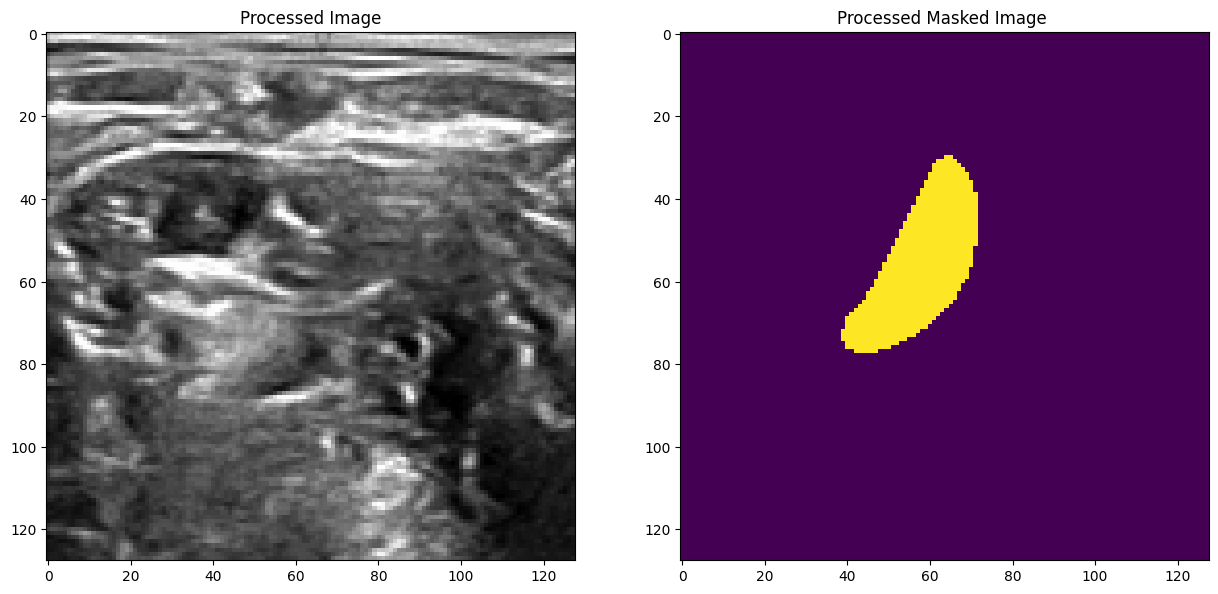

In [9]:
# Define the desired shape
target_shape_img = [128, 128, 3]
target_shape_mask = [128, 128, 1]

# Process data using apt helper function

X, y = PreprocessData(img, mask, target_shape_img, target_shape_mask, path)

# QC the shape of output and classes in output dataset
print("X Shape:", X.shape)
print("y shape:", y.shape)
# There are 2 classes
print(np.unique(y))

# Visualize the output
image_index = 0
fig, arr = plt.subplots(1, 2, figsize=(15, 15))
arr[0].imshow(X[image_index])
arr[0].set_title('Processed Image')
arr[1].imshow(y[image_index,:,:,0])
arr[1].set_title('Processed Masked Image ')

# Modelo U-Net

**PREGUNTA**

1. Crea un modelo U-Net

In [10]:
## Seeding
seed = 2019
random.seed = seed
np.random.seed = seed
tf.seed = seed

In [11]:
IMG_HEIGHT = 128
IMG_WIDTH  = 128
CHANNELS = 3

In [12]:
def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)):
    inputs = Input(input_size)

    # Encoder
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(conv5)

    # Decoder
    up6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    merge6 = concatenate([conv4, up6], axis=3)
    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(merge6)
    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)

    up7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(merge7)
    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)

    up8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(merge8)
    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)

    up9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(merge9)
    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)

    # Output layer
    output = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = tf.keras.models.Model(inputs=inputs, outputs=output)

    model.compile(optimizer='adam', loss=binary_crossentropy, metrics=['accuracy'])

    return model

# Create the model
model = unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))

# Summary of the model
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 16, 16, 512)    │      2,097,664 │ conv2d_9[0][0]         │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 16, 16, 1024)   │              0 │ conv2d_7[0][0],        │
│                      

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

**PREGUNTA**

2. Muestra una imagen junto a su máscara

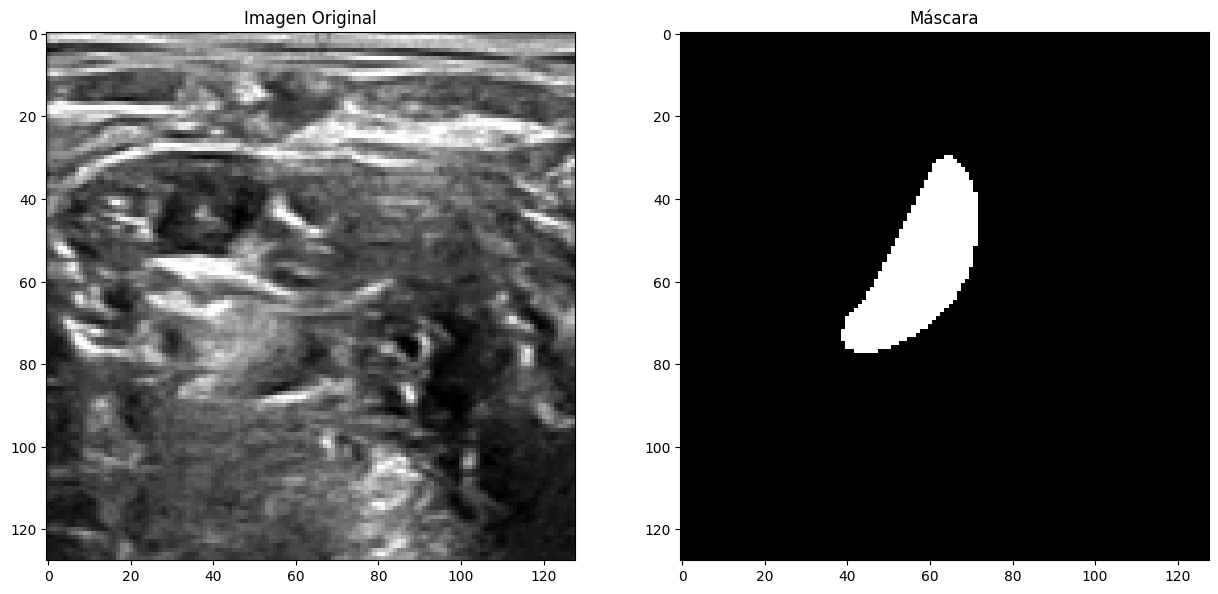

In [13]:
# Visualizar una imagen junto a su máscara
image_index = 0  # Puedes cambiar este índice para visualizar otras imágenes

# Crear una figura con dos subgráficas
fig, arr = plt.subplots(1, 2, figsize=(15, 15))

# Mostrar la imagen
arr[0].imshow(X[image_index])
arr[0].set_title('Imagen Original')

# Mostrar la máscara correspondiente
arr[1].imshow(y[image_index, :, :, 0], cmap='gray')
arr[1].set_title('Máscara')

# Mostrar la figura
plt.show()

**PREGUNTA**
3. Crea un conjunto de imágenes de test, junto con sus máscaras, con un 10% de las imágenes y máscaras de entrenamiento

In [14]:
# Dividir el conjunto de datos en 90% entrenamiento y 10% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

**PREGUNTA**

4. Entrena la U-net con early stopping maximizando el accuracy de validación (5 de paciencia). Entrena durante 25 épocas como máximo y vlidation_split del 10%
5. Calcula el accuracy del modelo con los datos de test.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Definir EarlyStopping para detener el entrenamiento si no hay mejora en el accuracy de validación
early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=5,
                               verbose=1,
                               restore_best_weights=True)

# Entrenar el modelo con EarlyStopping
history = model.fit(
    X_train,
    y_train,
    batch_size=8,
    epochs=25,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Calcular el accuracy del modelo con los datos de test
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 137s 182ms/step - accuracy: 0.9762 - loss: 0.1608 - val_accuracy: 0.9885 - val_loss: 0.0530
Epoch 2/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - accuracy: 0.9879 - loss: 0.0478 - val_accuracy: 0.9885 - val_loss: 0.0377
Epoch 3/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 84s 142ms/step - accuracy: 0.9880 - loss: 0.0435 - val_accuracy: 0.9897 - val_loss: 0.0283
Epoch 4/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 83s 143ms/step - accuracy: 0.9892 - loss: 0.0292 - val_accuracy: 0.9900 - val_loss: 0.0279
Epoch 5/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9896 - loss: 0.0276 - val_accuracy: 0.9905 - val_loss: 0.0256
Epoch 6/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9896 - loss: 0.0271 - val_accuracy: 0.9896 - val_loss: 0.0252
Epoch 7/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9901 - loss: 0.0254 - val_accuracy: 0.9912 - val_loss: 0.0252
Epoch 8/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9905 - loss: 

**PREGUNTA**

6. Realiza predicciones con los datos de test y muestra una imagen y máscara aleatoramiente de entre los datos de test.

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step


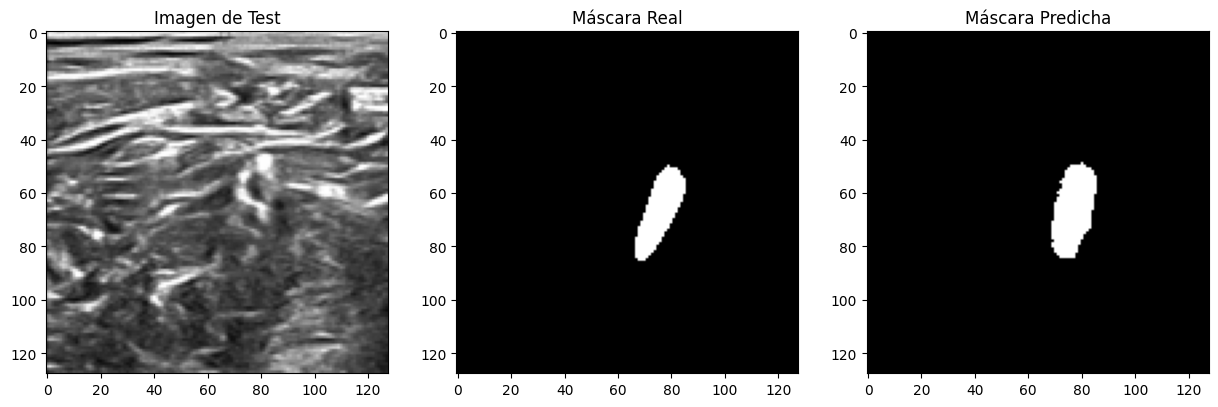

In [17]:
import random

# Realizar predicciones con los datos de test
predictions = model.predict(X_test)

# Seleccionar un índice aleatorio para mostrar una imagen y su máscara correspondiente
random_index = random.randint(0, len(X_test) - 1)

# Obtener la imagen, la máscara real y la predicción
image = X_test[random_index]
true_mask = y_test[random_index, :, :, 0]  # Máscara real (único canal)
predicted_mask = predictions[random_index, :, :, 0] > 0.5  # Predicción binaria (>0.5 para activar)

# Visualizar la imagen junto con su máscara real y predicción
fig, arr = plt.subplots(1, 3, figsize=(15, 15))
arr[0].imshow(image)
arr[0].set_title('Imagen de Test')

arr[1].imshow(true_mask, cmap='gray')
arr[1].set_title('Máscara Real')

arr[2].imshow(predicted_mask, cmap='gray')
arr[2].set_title('Máscara Predicha')

plt.show()

# Otras métricas

**PREGUNTA**

7. Prueba con las métricas (IoU y Dice) (en el Early Stopping también). Aprende cómo calcularlos aquí:

https://towardsdatascience.com/metrics-to-evaluate-your-semantic-segmentation-model-6bcb99639aa2

https://medium.com/@nghihuynh_37300/understanding-evaluation-metrics-in-medical-image-segmentation-d289a373a3f#:~:text=Dice%20coefficient%20%3D%20F1%20score%3A%20a,recall%2C%20or%20vice%2Dversa.


Sólo empieza a entrenar los modelos. No es necesario que termines. El tiempo de ejecución es bastante mayor

Aquí tenéis el código para calcular las métricas.

In [31]:
from tensorflow.keras import backend as K  # Import K from tensorflow.keras

def iou_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(tf.abs(y_true * y_pred), axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, [1, 2, 3]) + tf.reduce_sum(y_pred, [1, 2, 3]) - intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)  # Use K.mean from tensorflow.keras
    return iou

def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    dice = K.mean((2. * intersection + smooth) / (union + smooth), axis=0)  # Use K.mean from tensorflow.keras
    return dice

In [32]:
# Definir EarlyStopping para detener el entrenamiento si no hay mejora en el IoU de validación
early_stopping = EarlyStopping(monitor='val_iou_coef', # Cambiado a 'val_iou_coef'
                               patience=5,
                               verbose=1,
                               restore_best_weights=True,
                               mode='max') # Modo 'max' para IoU

# Recompilar el modelo con las nuevas métricas
model.compile(optimizer='adam', loss=binary_crossentropy, metrics=['accuracy', iou_coef, dice_coef])

# Entrenar el modelo con EarlyStopping y las nuevas métricas
history = model.fit(
    X_train,
    y_train,
    batch_size=8,
    epochs=25,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluar el modelo con las nuevas métricas
test_loss, test_accuracy, test_iou, test_dice = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test IoU: {test_iou * 100:.2f}%")
print(f"Test Dice: {test_dice * 100:.2f}%")


Epoch 1/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 103s 153ms/step - accuracy: 0.9762 - dice_coef: 0.0231 - iou_coef: 0.0147 - loss: 0.0955 - val_accuracy: 0.9885 - val_dice_coef: 0.0693 - val_iou_coef: 0.0407 - val_loss: 0.0385
Epoch 2/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 80s 141ms/step - accuracy: 0.9877 - dice_coef: 0.0755 - iou_coef: 0.0440 - loss: 0.0430 - val_accuracy: 0.9885 - val_dice_coef: 0.0482 - val_iou_coef: 0.0436 - val_loss: 0.0640
Epoch 3/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9878 - dice_coef: 0.0732 - iou_coef: 0.0432 - loss: 0.0444 - val_accuracy: 0.9885 - val_dice_coef: 0.0926 - val_iou_coef: 0.0546 - val_loss: 0.0373
Epoch 4/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 83s 144ms/step - accuracy: 0.9884 - dice_coef: 0.0823 - iou_coef: 0.0486 - loss: 0.0391 - val_accuracy: 0.9885 - val_dice_coef: 0.0727 - val_iou_coef: 0.0447 - val_loss: 0.0409
Epoch 5/25
571/571 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.9880 - dice_coef: 0.1051 - iou_coef: 0.0643 - loss: 0.0383 - v